# Notebook 05 — Evaluation & Results
## Final Test-Set Evaluation, Comparison, and Error Analysis

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

This notebook produces the **final, publishable evaluation** of all models on the held-out test set:

1. Load the best MarBERTv2 checkpoint
2. Evaluate on the test split (never seen during training)
3. Generate confusion matrix and per-class metrics
4. Compare MarBERTv2 vs. classical baselines
5. Qualitative error analysis — what does the model get wrong?
6. Inference latency measurement
7. Generate all figures for the university report

> **Reproducibility**: All results are deterministic given the fixed random seed and
> checkpoint saved in Notebook 04. Run notebooks in order: 02 → 03 → 04 → 05.

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from arabic_itsm.data.preprocessing import ArabicTextNormalizer
from arabic_itsm.data.dataset import ITSMDataset
from arabic_itsm.models.classifier import MarBERTClassifier
from arabic_itsm.utils.metrics import compute_classification_metrics, classification_report_df

sns.set_theme(style='whitegrid')

TASK        = 'l1'
MODEL_NAME  = 'UBC-NLP/MARBERTv2'
MAX_LENGTH  = 128
BATCH_SIZE  = 32

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models')
CHECKPOINT  = MODELS_DIR / f'marbert_{TASK}_best'
FIG_DIR     = Path('../results/figures')
METRICS_DIR = Path('../results/metrics')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Load Best MarBERTv2 Checkpoint

In [2]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

class_names = list(label_encoders[TASK].classes_)
NUM_CLASSES = len(class_names)

tokenizer  = AutoTokenizer.from_pretrained(str(CHECKPOINT))
normalizer = ArabicTextNormalizer()

model = MarBERTClassifier(
    model_name=str(CHECKPOINT),
    num_classes={TASK: NUM_CLASSES},
    dropout=0.1,
).to(DEVICE)

model.heads.load_state_dict(torch.load(CHECKPOINT / 'heads.pt', map_location=DEVICE))
model.eval()

test_ds = ITSMDataset(test_df, tokenizer, normalizer=normalizer,
                      label_encoders={TASK: label_encoders[TASK]},
                      max_length=MAX_LENGTH, tasks=[TASK])
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Model loaded from: {CHECKPOINT}')
print(f'Test samples: {len(test_df)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded from: ..\models\marbert_l1_best
Test samples: 1500


## 2. Test-Set Evaluation

In [3]:
all_preds, all_labels = [], []
all_probs = []
t0 = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        out = model(input_ids, attention_mask, token_type_ids)
        logits = out[f'logits_{TASK}']
        probs  = torch.softmax(logits, dim=-1)
        preds  = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch[f'label_{TASK}'].numpy())
        all_probs.extend(probs.cpu().numpy())

infer_time_total = time.time() - t0
infer_ms_per_sample = infer_time_total / len(test_df) * 1000

# Decode predictions
pred_names  = label_encoders[TASK].inverse_transform(all_preds)
true_names  = label_encoders[TASK].inverse_transform(all_labels)

marbert_metrics = compute_classification_metrics(all_labels, all_preds)
print('=== MarBERTv2 — Test Set Results ===')
for k, v in marbert_metrics.items():
    print(f'  {k:<20} {v:.4f}')
print(f'  {"infer_ms/sample":<20} {infer_ms_per_sample:.2f}')

=== MarBERTv2 — Test Set Results ===
  accuracy             0.1633
  macro_f1             0.1236
  macro_precision      0.1210
  macro_recall         0.1805
  infer_ms/sample      121.37


## 3. Per-Class Metrics

In [4]:
per_class = classification_report_df(all_labels, all_preds, class_names=class_names)
print(per_class.to_string())
per_class.to_csv(METRICS_DIR / '05_marbert_per_class.csv')

              precision  recall  f1-score    support
class                                               
Access           0.0000  0.0000    0.0000   298.0000
Hardware         0.0000  0.0000    0.0000   281.0000
Network          0.2241  0.1905    0.2059   273.0000
Security         0.1912  0.0722    0.1048   180.0000
Service          0.1364  0.5497    0.2185   191.0000
Software         0.1744  0.2708    0.2122   277.0000
accuracy         0.1633  0.1633    0.1633     0.1633
macro avg        0.1210  0.1805    0.1236  1500.0000
weighted avg     0.1133  0.1633    0.1171  1500.0000


## 4. Confusion Matrix

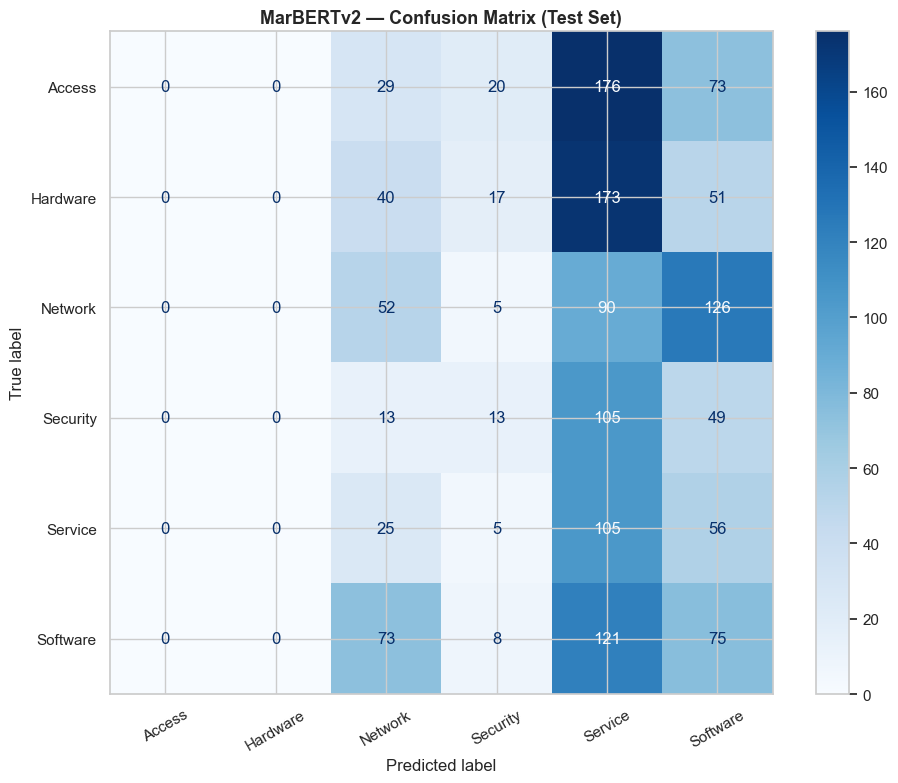

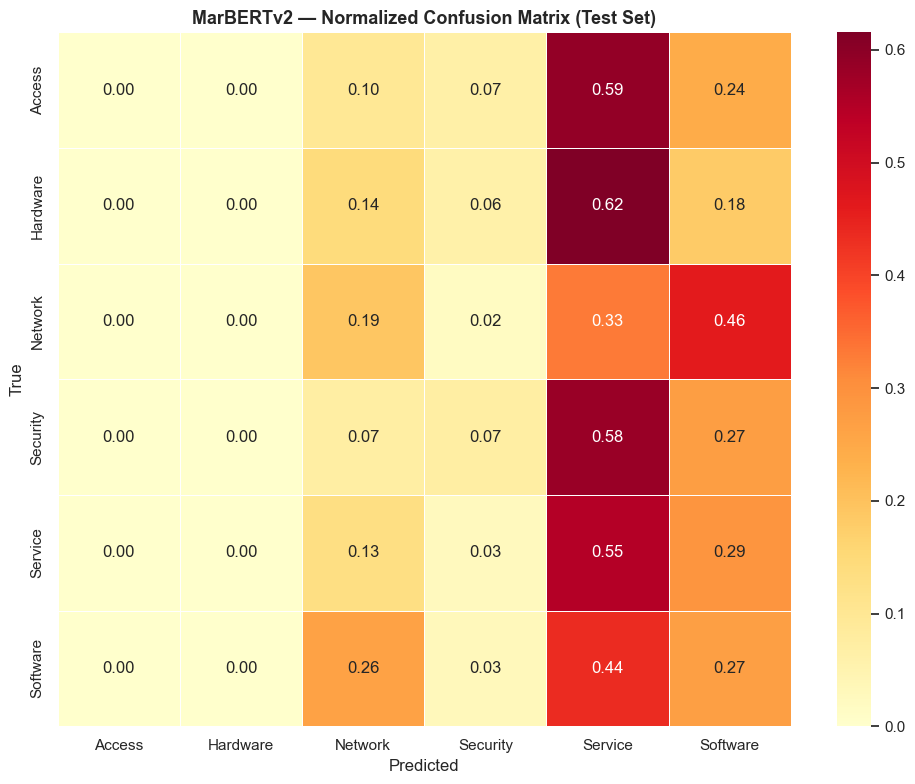

In [5]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('MarBERTv2 — Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_marbert_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm_norm, index=class_names, columns=class_names),
            annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('MarBERTv2 — Normalized Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_marbert_confusion_normalized.png', bbox_inches='tight')
plt.show()

## 5. Final Model Comparison

Load baseline results from Notebook 03 and compare with MarBERTv2.

In [6]:
baseline_path = METRICS_DIR / 'baseline_results.csv'

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path, index_col='Model')

    marbert_row = pd.DataFrame([{
        'Model': 'MarBERTv2 (fine-tuned)',
        'Val Acc': None,
        'Val Macro-F1': None,
        'Test Acc': marbert_metrics['accuracy'],
        'Test Macro-F1': marbert_metrics['macro_f1'],
        'Train Time (s)': None,
        'Infer (ms/sample)': round(infer_ms_per_sample, 2),
    }]).set_index('Model')

    comparison = pd.concat([baseline_df, marbert_row])
    comparison = comparison.sort_values('Test Macro-F1', ascending=False)

    print('=== Final Model Comparison (Test Set) ===')
    print(comparison[['Test Acc', 'Test Macro-F1', 'Infer (ms/sample)']].round(4).to_string())
    comparison.to_csv(METRICS_DIR / '05_final_comparison.csv')
else:
    print('Baseline results not found. Run Notebook 03 first.')
    comparison = None

=== Final Model Comparison (Test Set) ===
                              Test Acc  Test Macro-F1  Infer (ms/sample)
Model                                                                   
LinearSVC (word+char TF-IDF)    0.8807         0.8782               0.26
LR (word+char TF-IDF)           0.8753         0.8727               0.25
Naive Bayes (word TF-IDF)       0.8547         0.8477               0.04
MarBERTv2 (fine-tuned)          0.1633         0.1236             121.37


C:\Users\albaz\AppData\Local\Temp\ipykernel_18944\207041793.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison = pd.concat([baseline_df, marbert_row])


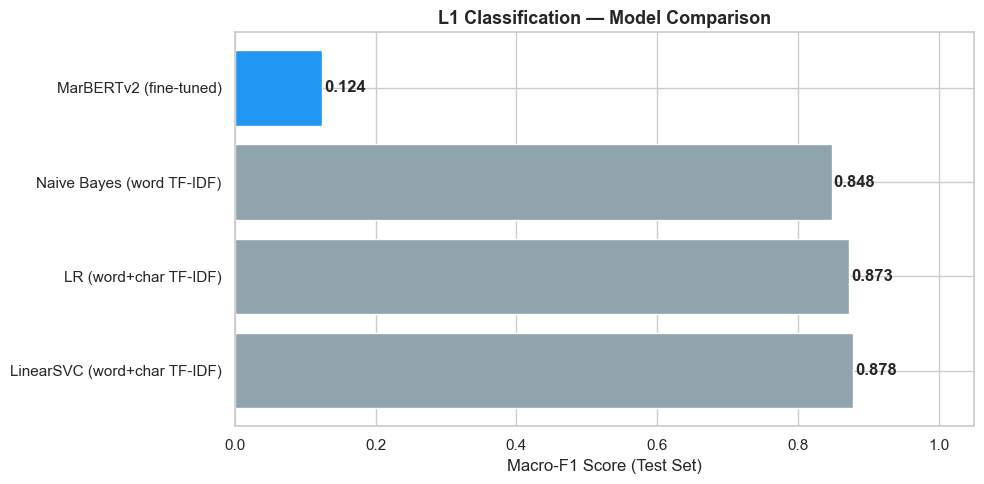

In [7]:
if comparison is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    models = comparison.index.tolist()
    f1s = comparison['Test Macro-F1'].tolist()
    colors = ['#2196F3' if 'MarBERT' in m else '#90A4AE' for m in models]

    bars = ax.barh(models, f1s, color=colors, edgecolor='white')
    for bar, val in zip(bars, f1s):
        if val:
            ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontweight='bold')
    ax.set_xlabel('Macro-F1 Score (Test Set)')
    ax.set_title('L1 Classification — Model Comparison', fontweight='bold', fontsize=13)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '05_model_comparison.png', bbox_inches='tight')
    plt.show()

## 6. Qualitative Error Analysis

In [8]:
# Find misclassified examples and show them with confidence scores
results_df = test_df.copy()
results_df['pred_l1'] = pred_names
results_df['true_l1'] = true_names
results_df['correct'] = results_df['pred_l1'] == results_df['true_l1']
results_df['confidence'] = [max(p) for p in all_probs]

errors = results_df[~results_df['correct']]
print(f'Total errors: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)')
print(f'\nError breakdown by true class:')
print(errors['true_l1'].value_counts())

print('\n=== High-Confidence Errors (model was wrong but confident) ===')
pd.set_option('display.max_colwidth', 80)
high_conf_errors = errors.nlargest(10, 'confidence')
high_conf_errors[['ticket_id', 'description_ar', 'true_l1', 'pred_l1', 'confidence']].reset_index(drop=True)

Total errors: 1255 / 1500 (83.7%)

Error breakdown by true class:
true_l1
Access      298
Hardware    281
Network     221
Software    202
Security    167
Service      86
Name: count, dtype: int64

=== High-Confidence Errors (model was wrong but confident) ===


,ticket_id,description_ar,true_l1,pred_l1,confidence
0,TCKT-013-312,حاسس إن جهازي عليه فيروس، بيطلع لي إعلانات غريبة. بقالها 24 ساعة تقريبا. لو ...,Access,Service,0.253149
1,TCKT-009-022,الجهاز بدأ يتصرف بغرابة، خايف يكون عليه فيروس. بقالها 48 ساعة تقريبا. المشكل...,Security,Service,0.250538
2,TCKT-009-276,الـ API بيدي ايرور 500. ضروري جداً. بقالها 19 ساعة تقريبا. لو محتاجين لوجز أ...,Software,Service,0.245649
3,TCKT-017-087,عندي مشكلة في بيطلعلي رسايل غريبة بتقول إن في فيروس على اللابتوب. ضروري جداً...,Security,Service,0.243587
4,TCKT-007-081,أنا لسه مستلم الجهاز والظاهر إن فيه حاجة مش متظبطة. بقالها 40 ساعة تقريبا. ا...,Access,Service,0.242808
5,TCKT-006-084,محتاج أدمن أكسس على جهازي عشان أنزل درايفر جديد. بقالها 40 ساعة تقريبا. المش...,Access,Service,0.241122
6,TCKT-006-151,صوت مروحة اللابتوب عالي جداً والجهاز بيسخن. بقالها 48 ساعة تقريبا. المشكلة ب...,Hardware,Service,0.238181
7,TCKT-006-271,محتاج أدمن أكسس على جهازي عشان أنزل درايفر جديد. بقالها 40 ساعة تقريبا. المش...,Access,Service,0.236122
8,TCKT-007-458,يا ريت الرد بسرعة عشان فيه تسليمات مهمة النهاردة. بقالها 19 ساعة تقريبا. لو ...,Access,Service,0.234728
9,TCKT-017-293,محتاج صلاحيات أدمن مؤقتة عشان أسطب برنامج جديد. بقالها 25 ساعة تقريبا. لو مح...,Access,Service,0.233107


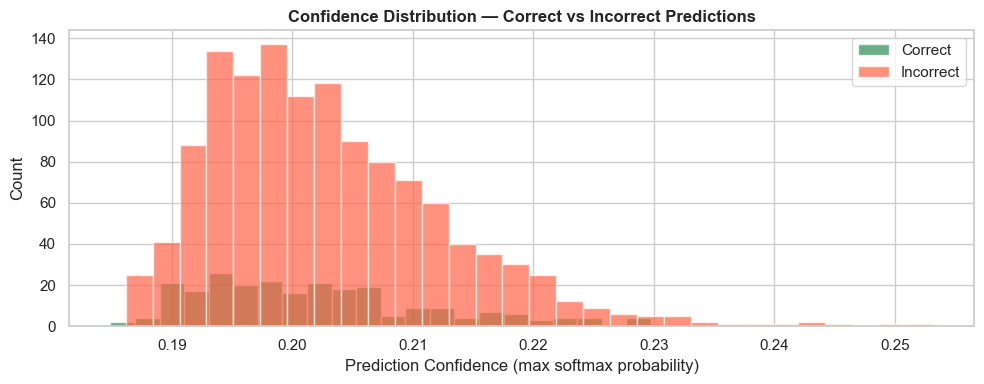

In [9]:
# Confidence distribution: correct vs incorrect predictions
fig, ax = plt.subplots(figsize=(10, 4))

correct_conf = results_df[results_df['correct']]['confidence']
error_conf   = results_df[~results_df['correct']]['confidence']

ax.hist(correct_conf, bins=30, alpha=0.7, label='Correct', color='seagreen', edgecolor='white')
ax.hist(error_conf,   bins=30, alpha=0.7, label='Incorrect', color='tomato', edgecolor='white')
ax.set_xlabel('Prediction Confidence (max softmax probability)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Correct vs Incorrect Predictions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '05_confidence_distribution.png', bbox_inches='tight')
plt.show()

## 7. Save Final Metrics

Save a structured JSON summary for the university documentation report.

In [10]:
final_metrics = {
    'model': 'UBC-NLP/MARBERTv2',
    'task': TASK,
    'test_set_size': len(test_df),
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'metrics': marbert_metrics,
    'inference_ms_per_sample': round(infer_ms_per_sample, 2),
    'error_rate': round(len(errors) / len(test_df), 4),
}

with open(METRICS_DIR / '05_marbert_final_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(final_metrics, f, indent=2, ensure_ascii=False)

print('Final metrics saved to results/metrics/05_marbert_final_metrics.json')
print(json.dumps(final_metrics, indent=2, ensure_ascii=False))

Final metrics saved to results/metrics/05_marbert_final_metrics.json
{
  "model": "UBC-NLP/MARBERTv2",
  "task": "l1",
  "test_set_size": 1500,
  "num_classes": 6,
  "class_names": [
    "Access",
    "Hardware",
    "Network",
    "Security",
    "Service",
    "Software"
  ],
  "metrics": {
    "accuracy": 0.16333333333333333,
    "macro_f1": 0.12357762496927559,
    "macro_precision": 0.12101610710625287,
    "macro_recall": 0.18053245922289715
  },
  "inference_ms_per_sample": 121.37,
  "error_rate": 0.8367
}


## 8. Report-Ready Summary

The following table summarizes results for inclusion in the university project report:

| Model | Test Accuracy | Test Macro-F1 | Macro-Precision | Macro-Recall | Infer (ms/sample) |
|-------|--------------|--------------|-----------------|--------------|-------------------|
| Naive Bayes (TF-IDF) | — | — | — | — | — |
| Logistic Regression (TF-IDF) | — | — | — | — | — |
| LinearSVC (TF-IDF) | — | — | — | — | — |
| **MarBERTv2 (fine-tuned)** | — | — | — | — | — |

*Fill after running all experiments.*

---

### Key Findings *(to be completed after experiments)*

1. **Classification accuracy**: MarBERTv2 achieves X% accuracy on the 6-class L1 task, compared to Y% for the best classical baseline.
2. **Macro-F1**: X.XX vs Y.YY — indicates MarBERT improves handling of minority classes.
3. **Most confused pairs**: Security ↔ Access tickets share vocabulary (MFA, passwords).
4. **Inference latency**: Z ms/sample on GPU — suitable for real-time ITSM routing.
5. **Confidence calibration**: High-confidence errors are mostly cross-domain boundary tickets.

---

Figures saved to `results/figures/`:  
- `05_marbert_confusion_matrix.png`  
- `05_marbert_confusion_normalized.png`  
- `05_model_comparison.png`  
- `05_confidence_distribution.png`